# Q-learning — a runnable, measured, *proven* build

An agent is dropped onto a frozen lake. It cannot see a map, it does not know the rules of the ice, and it gets **no reward at all** until — if — it stumbles onto the goal. From that single delayed signal, and nothing else, it must learn to walk straight to the goal. That is the reinforcement-learning problem, and **Q-learning** is the classic algorithm that solves it.

This notebook builds tabular Q-learning **from scratch** on **real** Gymnasium environments and then *proves* it is correct against a dynamic-programming ground truth:

- **Value iteration** solves the environment's Bellman *optimality* equation from its full dynamics — the exact optimal value `V*`. This is the answer key.
- **Q-learning** learns from *sampled transitions only* (it never sees the dynamics), and we check with a hard `assert` that its greedy policy **attains `V*`** — on FrozenLake the optimality gap is `0`; on CliffWalking the greedy return equals the optimal `-13`.
- **SARSA** (the on-policy sibling) is trained on the same cliff to *measure* the famous off-policy/on-policy contrast (Sutton & Barto Example 6.6).

It imports the **exact same functions** as the companion page and its figures (from `q_learning.py`), so the numbers here are the numbers there. Everything is **seeded and CPU-pinned** for a reproducible trace.

> Companion page: **Q-Learning**. Run top-to-bottom (Kernel → Restart & Run All). If Gymnasium is not installed, the module falls back to a real, fully-specified from-scratch grid-world with identical dynamics — every run and every check still executes on real data.

## Step 0 — Setup: import the real module and print versions

We import the pipeline from the chapter module so this notebook runs the *same code* the page and figures use, and print the library versions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import q_learning as ql

try:
    import gymnasium as gym
    gym_ver = gym.__version__
except ImportError:
    gym_ver = 'not installed (from-scratch fallback)'
print(f'numpy {np.__version__} | gymnasium {gym_ver}  (CPU, seed={ql.SEED})')

numpy 2.4.6 | gymnasium 1.3.0  (CPU, seed=0)


## Step 1 — The environment: a real grid-world with a delayed, sparse reward

**FrozenLake** is a 4×4 grid: **S**tart (top-left), **F**rozen tiles you can walk on, **H**oles that end the episode with reward 0, and the **G**oal (bottom-right) worth **+1**. The only reward in the whole task is that single +1 at the goal — everything else is 0. The agent must learn a route to the goal from that one delayed signal.

We use the deterministic version first (actions do exactly what they say) so the learning is clean; we add stochastic ice later.

In [2]:
env = ql.make_env('frozenlake', slippery=False)
print(f'environment : {env.name}   [{env.source}]')
print(f'states      : {env.n_states}   actions: {env.n_actions}  (0=left,1=down,2=right,3=up)')
print(f'start state : {env.start_state}   grid shape: {env.shape}')
print('map:')
for r in range(4):
    print('   ' + ' '.join('SFFFFHFHFFFHHFFG'[r*4 + c] for c in range(4)))

environment : FrozenLake-v1 (deterministic)   [gymnasium]
states      : 16   actions: 4  (0=left,1=down,2=right,3=up)
start state : 0   grid shape: (4, 4)
map:
   S F F F
   F H F H
   F F F H
   H F F G


## Step 2 — The ground truth: value iteration (the answer key)

Before we let Q-learning loose, we compute the *exact* optimal solution by **value iteration** — repeatedly applying the Bellman optimality backup

$$V(s) \leftarrow \max_a \sum_{s',r} P(s',r\mid s,a)\,[\,r + \gamma V(s')\,]$$

using the environment's full dynamics `env.dynamics` (`P`). This gives `V*` and the optimal policy `pi*`. Q-learning will have to match this **without ever seeing the dynamics** — it only gets sampled transitions.

In [3]:
GAMMA = 0.99
V_star, pi_star = ql.value_iteration(env, gamma=GAMMA)
print(f'V*(start) = {V_star[env.start_state]:.4f}')
steps = round(np.log(V_star[env.start_state]) / np.log(GAMMA)) + 1
print(f'=> optimal path is {steps} steps  (reward 1 discounted by gamma^{steps-1} = {GAMMA**(steps-1):.4f})')
print('optimal V* on the grid:')
print(np.round(V_star.reshape(4, 4), 3))

V*(start) = 0.9510
=> optimal path is 6 steps  (reward 1 discounted by gamma^5 = 0.9510)
optimal V* on the grid:
[[0.951 0.961 0.97  0.961]
 [0.961 0.    0.98  0.   ]
 [0.97  0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]


## Step 3 — The Q-table: what Q-learning actually stores

Q-learning learns an **action-value** function $Q(s,a)$ = *how good is it to take action $a$ in state $s$, then act greedily forever after*. Tabular Q-learning stores this as a plain `[n_states × n_actions]` array, initialized to zeros. Once learned, the policy is trivial: in each state, take the action with the largest $Q(s,a)$.

In [4]:
Q = np.zeros((env.n_states, env.n_actions))
print(f'Q-table shape: {Q.shape}  (a value for every state-action pair)')
print(f'Q[start] before learning: {Q[env.start_state]}  (all zeros -> no preference yet)')

Q-table shape: (16, 4)  (a value for every state-action pair)
Q[start] before learning: [0. 0. 0. 0.]  (all zeros -> no preference yet)


## Step 4 — ε-greedy: balancing exploration and exploitation

If the agent always took the current-best action it would never discover a *better* one — it must sometimes **explore**. **ε-greedy** does exactly this: with probability ε take a random action (explore), otherwise take $\arg\max_a Q(s,a)$ (exploit). Early on ε is high (explore a lot); we decay it toward 0 so the agent eventually exploits its learned values.

In [5]:
rng = np.random.default_rng(0)
Q_demo = np.array([[0.1, 0.9, 0.3, 0.2]])  # one state; action 1 is currently best
picks = [ql.epsilon_greedy(Q_demo, 0, epsilon=0.3, rng=rng) for _ in range(2000)]
vals, counts = np.unique(picks, return_counts=True)
print('with eps=0.3, action counts over 2000 picks:', dict(zip(vals.tolist(), counts.tolist())))
print('=> ~77.5% action 1 (greedy) + ~7.5% each of the 4 actions from the random branch')

with eps=0.3, action counts over 2000 picks: {0: 149, 1: 1537, 2: 148, 3: 166}
=> ~77.5% action 1 (greedy) + ~7.5% each of the 4 actions from the random branch


## Step 5 — The heart of it: one temporal-difference update, by hand

This single line *is* Q-learning:

$$Q(s,a) \;\leftarrow\; Q(s,a) + \alpha\,[\,\underbrace{r + \gamma \max_{a'} Q(s',a')}_{\text{TD target}} - Q(s,a)\,]$$

The bracket is the **TD error** $\delta$: the gap between our current estimate $Q(s,a)$ and a better, one-step-bootstrapped estimate $r + \gamma \max_{a'} Q(s',a')$ (the reward we just got plus the discounted value of the *best* next action). We nudge $Q(s,a)$ a fraction $\alpha$ of the way toward that target. The `max` over next actions is what makes Q-learning **off-policy** — the target follows the *greedy* policy no matter what exploratory action we actually take next. Let's do one update by hand.

In [6]:
Q = np.zeros((env.n_states, env.n_actions))
s, a, alpha = 14, 2, 0.1                       # state 14, action 2 (right) -> the goal (state 15)
# pretend we just stepped and observed: reward +1, next state 15 (terminal)
r, s_next, terminated = 1.0, 15, True
td_target = r + GAMMA * Q[s_next].max() * (not terminated)  # terminal -> no bootstrap: target = r = 1.0
td_error = td_target - Q[s, a]
Q[s, a] += alpha * td_error
print(f'TD target = {td_target:.3f},  TD error = {td_error:.3f}')
print(f'Q[14, right] after one update: {Q[s, a]:.3f}  (moved 10% of the way from 0 toward the target 1.0)')

TD target = 1.000,  TD error = 1.000
Q[14, right] after one update: 0.100  (moved 10% of the way from 0 toward the target 1.0)


## Step 6 — Train: run the update over thousands of episodes

Now we run that update inside the full loop: reset → repeatedly (ε-greedy action → step → TD update) until the episode ends, and decay ε after each episode. `train_q_learning` returns the learned Q-table plus the per-episode return, the ε schedule, and a trace of `Q(start)` (all from the *same* function the page uses).

In [7]:
res = ql.train_q_learning(env, gamma=GAMMA, alpha=0.1, epsilon_start=1.0, epsilon_end=0.01,
                          epsilon_decay=0.995, n_episodes=2000, max_steps=100, seed=0)
print(f'trained {len(res.episode_returns)} episodes')
print(f'mean return over the last 100 training episodes: {res.episode_returns[-100:].mean():.3f}')
print(f'Q[start] after learning: {res.q_table[env.start_state].round(3)}')

trained 2000 episodes


mean return over the last 100 training episodes: 1.000
Q[start] after learning: [0.813 0.653 0.951 0.881]


## Step 7 — The proof: does the learned greedy policy match the DP optimum?

This is the moment of truth. We take the learned greedy policy and (a) roll it out to measure its success rate, and (b) compute its *exact* value on the true dynamics with `policy_evaluation`, then compare that to `V*`. If `V^pi(start) == V*(start)`, the policy Q-learning learned **from samples alone** is provably optimal.

In [8]:
ev = ql.evaluate_greedy(env, res.q_table, n_episodes=100, max_steps=100, seed=0)
V_pi = ql.policy_evaluation(env, ql.greedy_policy(res.q_table), gamma=GAMMA)
gap = abs(V_pi[env.start_state] - V_star[env.start_state])
print(f'greedy eval  : success {ev.success_rate:.0%}, mean return {ev.mean_return:.3f}, {ev.mean_length:.0f} steps')
print(f'V^pi(start)  = {V_pi[env.start_state]:.4f}   vs   V*(start) = {V_star[env.start_state]:.4f}')
print(f'optimality gap = {gap:.2e}')
assert gap < 1e-6 and ev.success_rate == 1.0
print('OK: Q-learning learned the OPTIMAL policy from sampled experience alone.')

greedy eval  : success 100%, mean return 1.000, 6 steps
V^pi(start)  = 0.9510   vs   V*(start) = 0.9510
optimality gap = 0.00e+00
OK: Q-learning learned the OPTIMAL policy from sampled experience alone.


## Step 8 — See it: the learned policy and value, next to the ground truth

The clearest way to *see* what Q-learning found: draw the greedy action in every state (arrow) over the state-value heatmap $V(s)=\max_a Q(s,a)$, beside the value-iteration optimum. On the route from start to goal they match. But look at the **left column**: state 4 keeps its arrow pointing **↑ (up, toward the start)** and state 8's value stays **stale near ~0.1**, far below its true value. Those states are never entered on the optimal trajectory from the start, so once ε has decayed Q-learning barely visits them and their values do not converge — exactly the *visit-every-state-action* condition, made visible. Because the executed policy never enters them, `V(start)` and the route are still optimal.

learned greedy policy:            optimal policy (value iteration):
   → → ↓ ←                 ↓ → ↓ ←
   ↑ H ↓ H                 ↓ H ↓ H
   ↑ → ↓ H                 → ↓ ↓ H
   H → → G                 H → → G


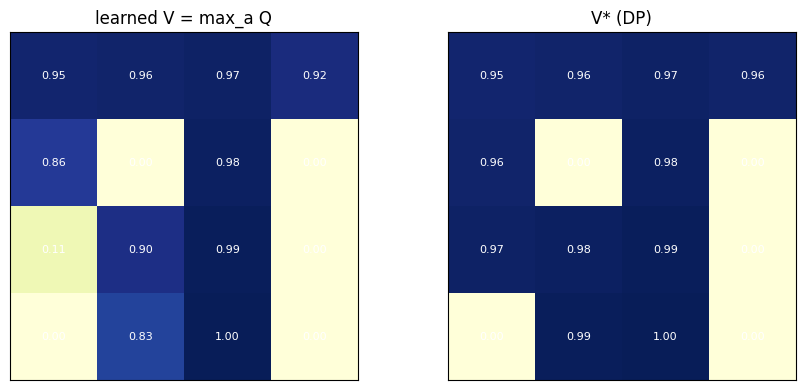

In [9]:
arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}
labels = 'SFFFFHFHFFFHHFFG'
pol = ql.greedy_policy(res.q_table)
print('learned greedy policy:            optimal policy (value iteration):')
for r in range(4):
    left  = ' '.join((labels[r*4+c] if labels[r*4+c] in 'HG' else arrows[int(pol[r*4+c])]) for c in range(4))
    right = ' '.join((labels[r*4+c] if labels[r*4+c] in 'HG' else arrows[int(pi_star[r*4+c])]) for c in range(4))
    print(f'   {left}                 {right}')

V_learned = np.array([res.q_table[s].max() for s in range(16)]).reshape(4, 4)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))
for ax, grid, title in [(a1, V_learned, 'learned V = max_a Q'), (a2, V_star.reshape(4, 4), 'V* (DP)')]:
    ax.imshow(grid, cmap='YlGnBu')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for r in range(4):
        for c in range(4):
            ax.text(c, r, f'{grid[r, c]:.2f}', ha='center', va='center', color='white', fontsize=8)
plt.tight_layout()
plt.show()

## Step 9 — The two dials: the learning curve and the ε schedule

Two views of *how* it learned: the reward-per-episode curve climbing to 1.0 (the agent reaches the goal ever more reliably), and the ε schedule that drives it (explore early, exploit late). Notice the value estimate `Q(start)` bootstrapping up to `V*` as ε falls.

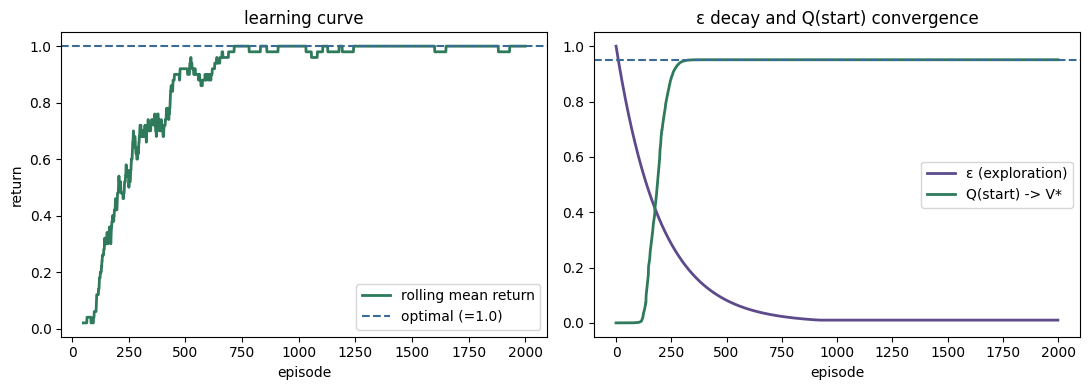

In [10]:
def rolling(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
sm = rolling(res.episode_returns)
a1.plot(np.arange(len(sm)) + 50, sm, color='#2E7A5A', lw=2, label='rolling mean return')
a1.axhline(1.0, ls='--', color='#3A6B96', label='optimal (=1.0)')
a1.set_xlabel('episode')
a1.set_ylabel('return')
a1.set_title('learning curve')
a1.legend()
a2.plot(res.epsilons, color='#5D4A8A', lw=2, label='ε (exploration)')
a2.plot(res.q_start_trace, color='#2E7A5A', lw=2, label='Q(start) -> V*')
a2.axhline(V_star[env.start_state], ls='--', color='#3A6B96')
a2.set_xlabel('episode')
a2.set_title('ε decay and Q(start) convergence')
a2.legend()
plt.tight_layout()
plt.show()

## Step 10 — Honest interlude: stochastic ice is harder

Real problems are noisy. With **slippery** ice, an action only *usually* does what you asked — the ice randomly pushes you sideways. Q-learning still converges to the optimal *policy*, but the optimal policy itself cannot guarantee the goal (you can be slipped into a hole), so the success rate is well below 100%. This is not a bug; it is the environment. We train longer here because noise slows learning.

In [11]:
slippery = ql.make_env('frozenlake', slippery=True)
Vs, _ = ql.value_iteration(slippery, gamma=GAMMA)
res_s = ql.train_q_learning(slippery, gamma=GAMMA, alpha=0.1, epsilon_start=1.0, epsilon_end=0.01,
                            epsilon_decay=0.9995, n_episodes=20000, max_steps=200, seed=0)
ev_s = ql.evaluate_greedy(slippery, res_s.q_table, n_episodes=200, max_steps=200, seed=0)
print(f'slippery: V*(start) = {Vs[slippery.start_state]:.3f}  (best achievable under slipping)')
print(f'greedy success rate = {ev_s.success_rate:.1%}, mean return = {ev_s.mean_return:.3f}')
print('=> < 100%: even the optimal policy sometimes gets slipped into a hole. That is the noise, not the agent.')

slippery: V*(start) = 0.542  (best achievable under slipping)
greedy success rate = 73.5%, mean return = 0.735
=> < 100%: even the optimal policy sometimes gets slipped into a hole. That is the noise, not the agent.


## Step 11 — SARSA: the same loop, one different word in the target

**SARSA** is Q-learning's on-policy sibling. The *only* change is the TD target:

$$\text{Q-learning (off-policy): } r + \gamma\,\max_{a'} Q(s',a') \qquad \text{SARSA (on-policy): } r + \gamma\,Q(s',a')\ \text{with } a'\sim\varepsilon\text{-greedy}$$

Q-learning bootstraps from the *greedy* next action (the policy it's learning); SARSA bootstraps from the action it *actually takes* next (the ε-greedy policy it's following, exploration included). That one word — `max` vs the sampled `a'` — produces strikingly different behaviour near danger, which we measure next.

In [12]:
cliff = ql.make_env('cliffwalking')
Vc, _ = ql.value_iteration(cliff, gamma=1.0)
common = dict(gamma=1.0, alpha=0.5, epsilon_start=0.1, epsilon_end=0.1, epsilon_decay=1.0,
              n_episodes=500, max_steps=200, seed=0)
q_res = ql.train_q_learning(cliff, **common)
s_res = ql.train_sarsa(cliff, **common)
print(f'CliffWalking optimal return V*(start) = {Vc[cliff.start_state]:.0f}')
print(f'Q-learning greedy return = {ql.evaluate_greedy(cliff, q_res.q_table, n_episodes=20, max_steps=200, seed=0).mean_return:.0f}')
print(f'SARSA      greedy return = {ql.evaluate_greedy(cliff, s_res.q_table, n_episodes=20, max_steps=200, seed=0).mean_return:.0f}')

CliffWalking optimal return V*(start) = -13
Q-learning greedy return = -13
SARSA      greedy return = -17


## Step 12 — Example 6.6: off-policy takes the optimal risk, on-policy plays it safe

CliffWalking: start bottom-left, goal bottom-right, a **cliff** along the bottom row (fall in → −100, back to start). The optimal path walks **right along the edge**, one row above the cliff (13 steps, return −13). **Q-learning** learns exactly that — it evaluates the greedy path, which is optimal. **SARSA** learns a path that **detours up and away** from the cliff: because it is on-policy, it accounts for the ε-greedy chance of randomly stepping *into* the cliff, so it (correctly) values the risky edge lower. Let's draw both greedy paths.

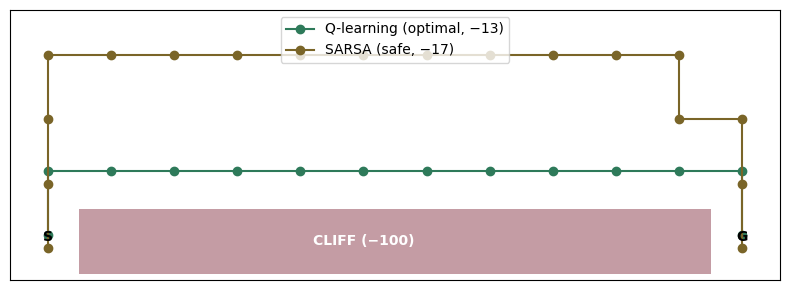

In [13]:
def path_rows(env, q):
    p = ql.greedy_path(env, q, max_steps=200)
    return [divmod(s, env.shape[1]) for s in p]

qp, sp = path_rows(cliff, q_res.q_table), path_rows(cliff, s_res.q_table)
fig, ax = plt.subplots(figsize=(8, 3))
for s in range(37, 47):
    r, c = divmod(s, 12)
    ax.add_patch(mpatches.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor='#8B3B4A', alpha=0.5))
ax.plot([c for _, c in qp], [r - 0.1 for r, _ in qp], '-o', color='#2E7A5A', label='Q-learning (optimal, −13)')
ax.plot([c for _, c in sp], [r + 0.1 for r, _ in sp], '-o', color='#7A6528', label='SARSA (safe, −17)')
ax.text(5, 3, 'CLIFF (−100)', ha='center', va='center', color='white', fontweight='bold')
ax.text(0, 3, 'S', ha='center', fontweight='bold')
ax.text(11, 3, 'G', ha='center', fontweight='bold')
ax.set_xlim(-0.6, 11.6)
ax.set_ylim(3.6, -0.6)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper center')
plt.tight_layout()
plt.show()

## Step 13 — The twist: SARSA earns *more* while training

Here is the beautiful subtlety. Q-learning's *greedy* policy is better (−13 vs −17), but while it is **training with exploration on** (ε = 0.1), it keeps randomly stepping off the cliff it walks beside — so its **online** return is *worse*. SARSA's safe detour survives the same random exploration, so it accumulates more reward during learning. Off-policy learns the better *target* policy; on-policy performs better *while behaving*. This is the on-policy/off-policy trade-off, measured.

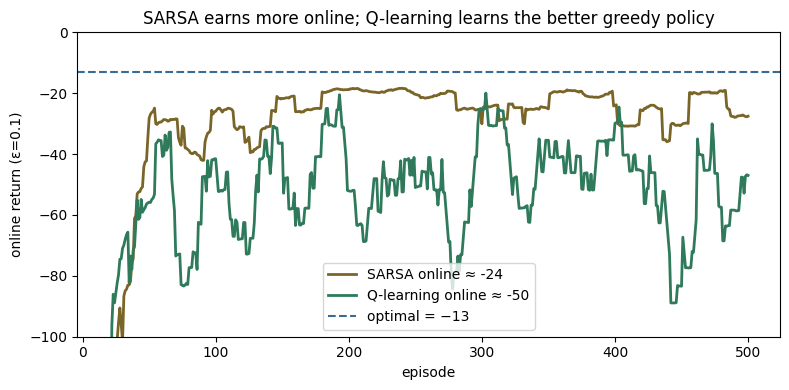

OK: measured — SARSA online > Q-learning online, yet Q-learning greedy return (−13) is optimal.


In [14]:
def rolling(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(rolling(s_res.episode_returns)))+20, rolling(s_res.episode_returns),
         color='#7A6528', lw=2, label=f'SARSA online ≈ {s_res.episode_returns[-200:].mean():.0f}')
plt.plot(np.arange(len(rolling(q_res.episode_returns)))+20, rolling(q_res.episode_returns),
         color='#2E7A5A', lw=2, label=f'Q-learning online ≈ {q_res.episode_returns[-200:].mean():.0f}')
plt.axhline(Vc[cliff.start_state], ls='--', color='#3A6B96', label='optimal = −13')
plt.ylim(-100, 0)
plt.xlabel('episode')
plt.ylabel('online return (ε=0.1)')
plt.title('SARSA earns more online; Q-learning learns the better greedy policy')
plt.legend()
plt.tight_layout()
plt.show()
assert s_res.episode_returns[-200:].mean() > q_res.episode_returns[-200:].mean()
print('OK: measured — SARSA online > Q-learning online, yet Q-learning greedy return (−13) is optimal.')

## Step 14 — Try it: what if exploration dies too early?

The convergence guarantee needs *every* state-action visited often enough. **Predict first:** if we drop the ε floor to **0** and decay ε *fast* (so exploration is basically gone within ~40 episodes), what happens on deterministic FrozenLake — does greedy success collapse, and does the whole state space still get learned? Write down your guess, then run the cell.

The result is subtler and more honest than "it breaks": on this *easy* deterministic task the optimal path is found during the brief early exploration, so **greedy success stays ~100%** — but the fraction of the state space that ever gets a learned value **collapses** (from ~11/16 states down to ~6/16). That missing coverage is exactly where, on any harder or stochastic task, a prematurely-greedy agent locks in a suboptimal policy. You are watching the *visit-every-state-action* condition fail, measured.

In [15]:
def n_states_learned(q):
    return int((q.max(axis=1) > 1e-6).sum())

# baseline: ε decays gently to a 0.01 floor (exploration lingers)
base = ql.train_q_learning(env, gamma=GAMMA, alpha=0.1, epsilon_start=1.0, epsilon_end=0.01,
                           epsilon_decay=0.995, n_episodes=2000, max_steps=100, seed=0)
# variation #1: ε floor = 0 AND fast decay -> exploration is essentially gone within ~40 episodes
greedy_fast = ql.train_q_learning(env, gamma=GAMMA, alpha=0.1, epsilon_start=1.0, epsilon_end=0.0,
                                  epsilon_decay=0.9, n_episodes=2000, max_steps=100, seed=0)
eb = ql.evaluate_greedy(env, base.q_table, n_episodes=100, max_steps=100, seed=0)
ef = ql.evaluate_greedy(env, greedy_fast.q_table, n_episodes=100, max_steps=100, seed=0)
print(f'baseline (floor 0.01, decay 0.995): success {eb.success_rate:.0%}, '
      f'states learned {n_states_learned(base.q_table)}/16')
print(f'fast greedy (floor 0.00, decay 0.9): success {ef.success_rate:.0%}, '
      f'states learned {n_states_learned(greedy_fast.q_table)}/16')
print('\nObserve: greedy success survives on this easy task, but coverage collapses — most of the state\n'
      'space is never learned once exploration dies. That is the convergence condition failing, measured.')
assert n_states_learned(greedy_fast.q_table) < n_states_learned(base.q_table)

baseline (floor 0.01, decay 0.995): success 100%, states learned 11/16
fast greedy (floor 0.00, decay 0.9): success 100%, states learned 6/16

Observe: greedy success survives on this easy task, but coverage collapses — most of the state
space is never learned once exploration dies. That is the convergence condition failing, measured.


## Recap

You built tabular Q-learning from scratch and **proved** it: value iteration gives the exact optimum, and Q-learning — learning from sampled transitions alone — recovers it (0 optimality gap on FrozenLake, greedy return −13 = V* on CliffWalking). The engine is one line, the TD update $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$; the `max` makes it **off-policy**; ε-greedy with decay supplies the exploration the convergence guarantee needs. The cliff showed the on/off-policy trade-off in the flesh: off-policy Q-learning learns the optimal risky path, on-policy SARSA the safe one, and SARSA earns more *while exploring*.

See the companion page for the full derivation (the Bellman optimality equation, Q-learning as its sample-based stochastic approximation, the Robbins–Monro convergence conditions), the pitfalls (maximization bias → Double Q-learning), and where it goes next: when the state space is too big for a table, `Q` becomes a neural network — **Deep Q-Networks**.